# Capstone 2 Project: EmporiUm Sales Analysis

This project analyzes sales performance for two EmporiUm territories in the South Region, focusing on South Carolina & Texas. I analyzed how each territory is performing in overall in-store sales, monthly revenue trends, and product & category performance. I also used a simple regression model to measure revenue growth over time. The goal is to compare both territories & decide which one should get more marketing focus for the next quarter.

In [3]:
# importing libraries needed for analysis

import numpy as np # fast numerical calculations
import pandas as pd # used for working with DataFrames (tables)
import matplotlib.pyplot as plt # creates visualization and charts
from sklearn.linear_model import LinearRegression # creates regression model

## Loading in CSV Files One-by-One

In [5]:
# file 1:
store_sales = pd.read_csv("Data/StoreSales.csv") # loading in StoreSales data

store_sales.info() # confirming all contents were imported

store_sales.head() #previewing table (top 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [6]:
# file 2:
store_detail = pd.read_csv("Data/StoreDetail.csv") # loading in StoreDetail data

store_detail.info() # confirming all contents were imported

store_detail.head() # previewing table (top 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [7]:
# file 3:
products = pd.read_csv("Data/Products.csv") # loading in Products data

products.info() # confirming all contents were imported

products.head() # previewing table (top 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [8]:
# file 4
product_categories = pd.read_csv("Data/ProductCategories.csv") # loading in ProductCategories data

product_categories.info() # confirming all contents were imported

product_categories.head() # previewing table (top 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [9]:
# file 5
customer_list = pd.read_csv("Data/customer_list.csv") # loading in customer_list data

customer_list.info() # confirming all contents were imported

customer_list.head() # previewing table (top 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB


,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


# Core Marketing Analysis

### Q1: Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?
- Identify the territory managers, store IDs, and cities for SC & TX

In [12]:
# filtering store_detail DataFrame (South Carolina & Texas)

territory_stores = store_detail[(store_detail['State'] == 'South Carolina')| # keeping SC stores
                                 (store_detail['State'] == 'Texas')] # keeping TX stores
                                 
# displaying store ID, city, state and manager
territory_stores[['Store ID', 'Store Location', 'State', 'Territory Manager']]

,Store ID,Store Location,State,Territory Manager
98,852,Charleston,South Carolina,Len Jensen
99,853,Greenville,South Carolina,Len Jensen
100,901,Arlington,Texas,"Jeff ""Howdy"" Richards"
101,902,Austin,Texas,"Jeff ""Howdy"" Richards"
102,903,Bacliff,Texas,"Jeff ""Howdy"" Richards"
103,904,Baytown,Texas,"Jeff ""Howdy"" Richards"
104,905,Beaumont,Texas,"Jeff ""Howdy"" Richards"
105,906,Cedar Park,Texas,"Jeff ""Howdy"" Richards"
106,907,Dallas,Texas,"Jeff ""Howdy"" Richards"
107,908,Denton,Texas,"Jeff ""Howdy"" Richards"


Terriroty Managers: SC - Len Jenson, TX - Jeff "Howdy" Richards

SC Store IDs: `852` & `853`

TX Store IDs: `901` - `911`

### Q2: What is the monthly revenue for in-store sales in each of the two sales territories, over the full period covered by the data?
- Monthly Total Revenue for In-Store Sales

In [15]:
# converting Transaction Date column (store_sales) to pandas datetime format
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date']) # making date usable

# creating a Month column from Transaction Date
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M') # extracting year & month

# merging State columns from store_detail using Store ID
sales_w_state = store_sales.merge(store_detail[['Store ID', 'State']], # Store ID + State
                                  on = 'Store ID') # matching rows using Store ID

# filtering to keep SC and TX only
territory_sales = sales_w_state[(sales_w_state['State'] == 'South Carolina')| # SC stores
                                (sales_w_state['State'] == 'Texas')] # TX stores

# grouping States, Month & total Sale Amount
monthly_revenue = territory_sales.groupby(# grouping by state & month
    ['State','Month'])['Sale Amount'].sum().reset_index() # total revenue for each group, resetting them as regular columns
   
#displaying output
monthly_revenue

,State,Month,Sale Amount
0,South Carolina,2022-01,9640.38
1,South Carolina,2022-02,9763.98
2,South Carolina,2022-03,8366.63
3,South Carolina,2022-04,8929.63
4,South Carolina,2022-05,5396.03
...,...,...,...
91,Texas,2025-08,98630.93
92,Texas,2025-09,109065.94
93,Texas,2025-10,168955.72
94,Texas,2025-11,105400.74


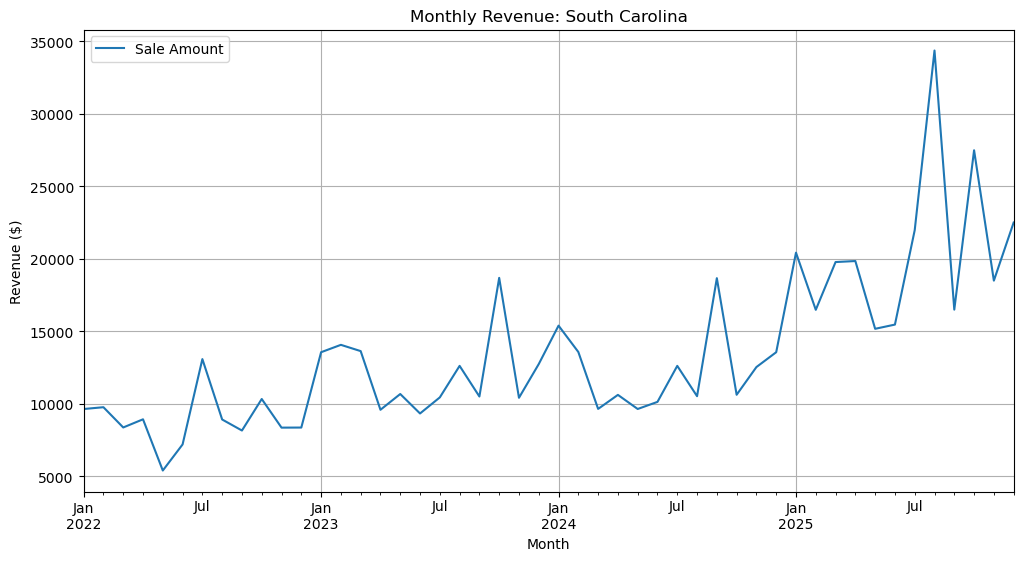

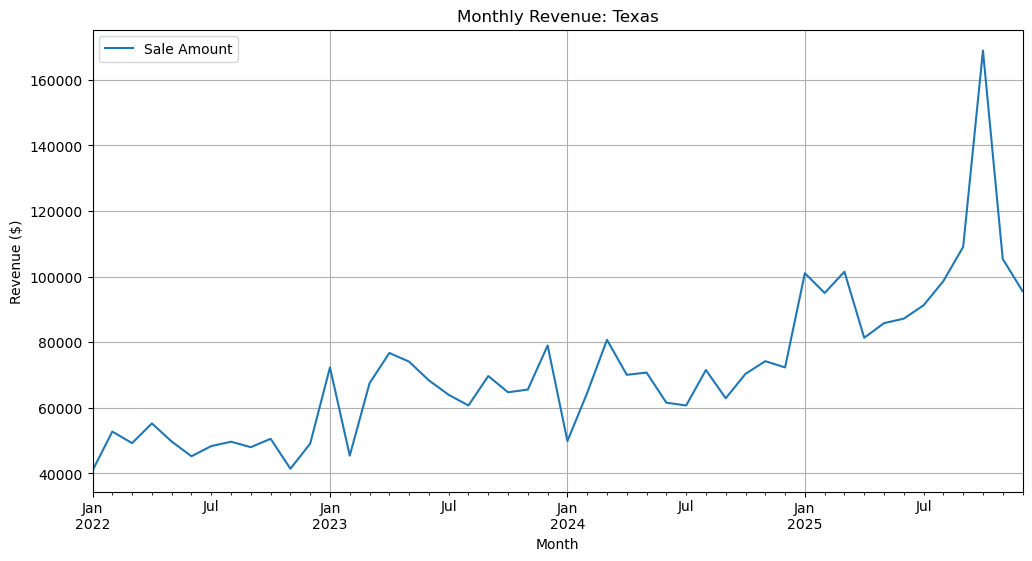

South Carolina - Monthly Revenue Trend: 287.56
Texas- Monthly Revenue Trend: 1309.38


In [16]:
# creating line chart for visual
month_rev_df = monthly_revenue # creating df

month_rev_df = month_rev_df.sort_values('Month') # sorts Month so line is in order

# filtering SC
sc_mr_df = month_rev_df[month_rev_df['State'] == 'South Carolina'] # SC only

# filtering TX
tx_mr_df = month_rev_df[month_rev_df['State'] == 'Texas'] # TX only

# plotting SC
sc_mr_df.plot(x='Month', y='Sale Amount', figsize=(12,6)) # creating a simple line chart
plt.title('Monthly Revenue: South Carolina') # chart title
plt.xlabel('Month') # x-axis label
plt.ylabel('Revenue ($)') # y-axis label
plt.grid(True) # adding grid lines
plt.show()

# plotting TX
tx_mr_df.plot(x='Month', y='Sale Amount', figsize=(12,6)) # creating a simple line chart
plt.title('Monthly Revenue: Texas') # chart title
plt.xlabel('Month') # x-axis label
plt.ylabel('Revenue ($)') # y-axis label
plt.grid(True) # adding grid lines
plt.show()

# creating regression for territories to measure revenue trend
sc_mr_df = sc_mr_df.sort_values('Month') # sorting SC by Month
sc_mr_df['Month_Index'] = range(len(sc_mr_df)) # numbering each month

# setting month index and revenue
X_sc = sc_mr_df[['Month_Index']] # number of month
y_sc = sc_mr_df['Sale Amount'] # revenue per month

tx_mr_df = tx_mr_df.sort_values('Month') # sorting TX by Month
tx_mr_df['Month_Index'] = range(len(tx_mr_df)) # numbering each month

# setting month index and revenue
X_tx = tx_mr_df[['Month_Index']] # number of month
y_tx = tx_mr_df['Sale Amount'] # revenue per month

# creating and fitting model
sc_model = LinearRegression()
sc_model.fit(X_sc,y_sc)

tx_model = LinearRegression()
tx_model.fit(X_tx,y_tx)

# pulling rate of change per month
sc_slope = sc_model.coef_[0]
tx_slope = tx_model.coef_[0]

print("South Carolina - Monthly Revenue Trend:",round(sc_slope, 2))
print("Texas- Monthly Revenue Trend:",round(tx_slope, 2))

Time Period: 2022-01 to 2025-12

Insight: Both of the states' monthly revenue fluctuates over time, but shows a gradual
increase throughout the time period. Texas reaches the highest total between the two,
and South Carolina shows a steadier increase over time. The regression trends confirm that South Carolina increases by roughly `$287.56` per month and Texas increases roughly `$1,309.38` per month.

### Q3: How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?
- Ranking Store Performance

In [19]:
# merging store_sales with store_detail on State info
sales_w_state = store_sales.merge(store_detail[['Store ID','State','Store Location']], # adding State from store_detail
                                  on = 'Store ID') # matching store ID

# filtering to keep SC & TX only
territory_sales = sales_w_state[(sales_w_state['State'] == 'South Carolina')| # SC stores
                                (sales_w_state['State'] == 'Texas')] # TX stores

# grouping by Store ID, Store Location & total State revenue
store_performance = territory_sales.groupby(['Store ID','Store Location','State'] # group by store,location,state
                                           )['Sale Amount'].sum().reset_index() # total revenue per store

# ranking stores in each state (1 = highest revenue)
store_performance['Rank'] = store_performance.groupby('State')['Sale Amount']\
                                            .rank(ascending=False) # 1 = highest revenue

# sorting by State then rank
store_performance = store_performance.sort_values(['State','Rank']) # clean sort

# separating tables
sc_stores = store_performance[store_performance['State'] == 'South Carolina'] # SC only
tx_stores = store_performance[store_performance['State'] == 'Texas'] # TX only

In [20]:
sc_stores # displaying output for SC

,Store ID,Store Location,State,Sale Amount,Rank
1,853,Greenville,South Carolina,337002.00,1.0
0,852,Charleston,South Carolina,311810.56,2.0


#### Top Performer SC:
Greenville with `$337,002` total revenue

In [22]:
tx_stores # displaying output for TX

,Store ID,Store Location,State,Sale Amount,Rank
6,905,Beaumont,Texas,637818.90,1.0
11,910,Fort Worth,Texas,351772.59,2.0
10,909,Desoto,Texas,330720.12,3.0
7,906,Cedar Park,Texas,312628.27,4.0
5,904,Baytown,Texas,298163.16,5.0
9,908,Denton,Texas,298111.45,6.0
2,901,Arlington,Texas,292987.49,7.0
3,902,Austin,Texas,291145.00,8.0
4,903,Bacliff,Texas,280714.34,9.0
12,911,Georgetown,Texas,269344.64,10.0


#### Top Performer TX:
Beaumont with `$637,818.90` total revenue

### Q4: Comparing the customer ID from the customer list data with the rewards ID fron the sales data, who were the top customers in each sales territory?
- Top Customers in Each Sales Territory

In [25]:
# splitting the single column into separate ones (taking str & splitting them on '|')
customer_list = customer_list['cust_id|date|time|name|email|phone|sms-opt-out '].str.split('|', expand=True)

# renaming new columns
customer_list.columns = ['Customer ID','Date','Time','Name','Email','Phone','SMS Opt Out']

# converting Customer ID to numeric
customer_list['Customer ID'] = customer_list['Customer ID'].astype(int)

In [26]:
# renaming RewardsID to pass merge syntax
store_sales = store_sales.rename(columns={'RewardsID':'Customer ID'})

# converting Customer ID to numeric
customer_list['Customer ID'] = customer_list['Customer ID'].astype(int)

# merging store_sales & customer_list to pull Customer ID & Name
sales_w_customers = store_sales.merge(customer_list[['Customer ID','Name']], # matching Customer ID & Name to Rewards ID
                                      on = 'Customer ID') # matching Customer ID

# merging store_detail to pull State
sales_w_state = sales_w_customers.merge(store_detail[['Store ID','State']], # adding State
                                        on = 'Store ID') # matching Store ID

# filtering to keep SC & TX only
territory_sales = sales_w_state[(sales_w_state['State'] == 'South Carolina')| # SC customers
                                (sales_w_state['State'] == 'Texas')] # TX customers

# grouping by Customer ID,Rewards ID & State on total spendings
customer_performance = territory_sales.groupby(['Customer ID','Name','State'] # grouping customer,ID,state
                                              )['Sale Amount'].sum().reset_index() # total spending per customer

# ranking customers in each state (1 = highest spender)
customer_performance['Rank'] = customer_performance.groupby('State')['Sale Amount']\
                                                    .rank(ascending=False)

# sorting by State then Rank
customer_performance = customer_performance.sort_values(['State','Rank'])

# separating tables
sc_customers = customer_performance[customer_performance['State'] == 'South Carolina'] # SC only
tx_customers = customer_performance[customer_performance['State'] == 'Texas'] # TX only

In [27]:
# previewing top 5 (SC)
sc_customers.head()

,Customer ID,Name,State,Sale Amount,Rank
523,340.0,Jin Kwon,South Carolina,1786.05,1.0
629,404.0,Roman Roy,South Carolina,1778.84,2.0
332,213.0,Jazz,South Carolina,1763.70,3.0
114,74.0,Ben Chang,South Carolina,1566.60,4.0
434,280.0,Cal Abar,South Carolina,1396.50,5.0


In [28]:
# the top spender (SC)
sc_customers.iloc[0]

Customer ID             340.0
Name                 Jin Kwon
State          South Carolina
Sale Amount           1786.05
Rank                      1.0
Name: 523, dtype: object

Jin Kwon (Customer 340) with a total spending of `$1,786.05`

In [30]:
# previewing the top 5 (TX)
tx_customers.head()

,Customer ID,Name,State,Sale Amount,Rank
531,344.0,Nate Jacobs,Texas,5240.86,1.0
743,474.0,Christopher Moltisanti,Texas,3479.46,2.0
158,102.0,Jodie L.,Texas,3464.91,3.0
265,168.0,Darius,Texas,3400.35,4.0
422,271.0,Maeby F.,Texas,3127.53,5.0


In [31]:
# the top spender (TX)
tx_customers.iloc[0]

Customer ID          344.0
Name           Nate Jacobs
State                Texas
Sale Amount        5240.86
Rank                   1.0
Name: 531, dtype: object

Nate Jacobs (Customer 344) with a total spending of `$5,240.86`

### Q5: What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?
- Monthly Transaction & Revenue by Product Category

In [34]:
# merging on product categories
territory_sales_cat = territory_sales.merge(products[['Prod Num','CategoryID']], # pulling CategoryID from products table
                                           on = 'Prod Num') # matching on product num

# merging category names
territory_sales_cat = territory_sales_cat.merge(
    product_categories[['CategoryID','Category']], # pulling Category names from product_cat
    on = 'CategoryID') # matching on CategoryID

# grouping State, Month & Category to pull monthly info
monthly_cat_stats = territory_sales_cat.groupby(['State','Month','Category'] # grouping territory,month,category
                                              ).agg(Transactons = ('Prod Num','count'), # counting number of transactions
                                                 Total_Revenue = ('Sale Amount','sum') # total sales
                                                   ).reset_index()

# ranking State & Month based on revenue
monthly_cat_stats['Rank'] = monthly_cat_stats.groupby(['State','Month']
                                                     )['Total_Revenue'].rank(ascending=False) # ranking categories for each month

In [35]:
# filtering monthly category stats for SC
sc_monthly_cat = monthly_cat_stats[monthly_cat_stats['State'] == 'South Carolina']

# sorting Month first then rank (1 = highest revenue)
sc_monthly_cat_sort = sc_monthly_cat.sort_values(['Month','Rank'])

# previewing SC
sc_monthly_cat_sort

,State,Month,Category,Transactons,Total_Revenue,Rank
3,South Carolina,2022-01,Textbooks,33,4302.43,1.0
1,South Carolina,2022-01,Art Supplies,11,267.08,2.0
0,South Carolina,2022-01,Apparel and Merchandise,16,96.00,3.0
2,South Carolina,2022-01,Books (General),4,81.44,4.0
8,South Carolina,2022-02,Technology & Accessories,7,4356.24,1.0
...,...,...,...,...,...,...
204,South Carolina,2025-11,Books (General),4,48.48,5.0
210,South Carolina,2025-12,Technology & Accessories,35,13622.42,1.0
211,South Carolina,2025-12,Textbooks,33,5832.42,2.0
208,South Carolina,2025-12,Apparel and Merchandise,32,614.40,3.0


In [36]:
# filtering mathly category stats for TX
tx_monthly_cat = monthly_cat_stats[monthly_cat_stats['State'] == 'Texas']

# sorting Month first then rank (1 = highest revenue)
tx_monthly_cat_sort = tx_monthly_cat.sort_values(['Month','Rank'])

# previewing TX
tx_monthly_cat_sort

,State,Month,Category,Transactons,Total_Revenue,Rank
217,Texas,2022-01,Textbooks,66,13659.03,1.0
216,Texas,2022-01,Technology & Accessories,21,13252.61,2.0
213,Texas,2022-01,Art Supplies,44,1710.06,3.0
215,Texas,2022-01,Stationery and Supplies,99,869.77,4.0
212,Texas,2022-01,Apparel and Merchandise,24,626.88,5.0
...,...,...,...,...,...,...
496,Texas,2025-12,Textbooks,88,14358.19,2.0
492,Texas,2025-12,Art Supplies,110,5351.94,3.0
491,Texas,2025-12,Apparel and Merchandise,128,4228.96,4.0
494,Texas,2025-12,Stationery and Supplies,209,2116.62,5.0


Average Revenue Per Category: South Carolina - $ 90123.4
Average Revenue Per Category: Texas - $ 449931.35


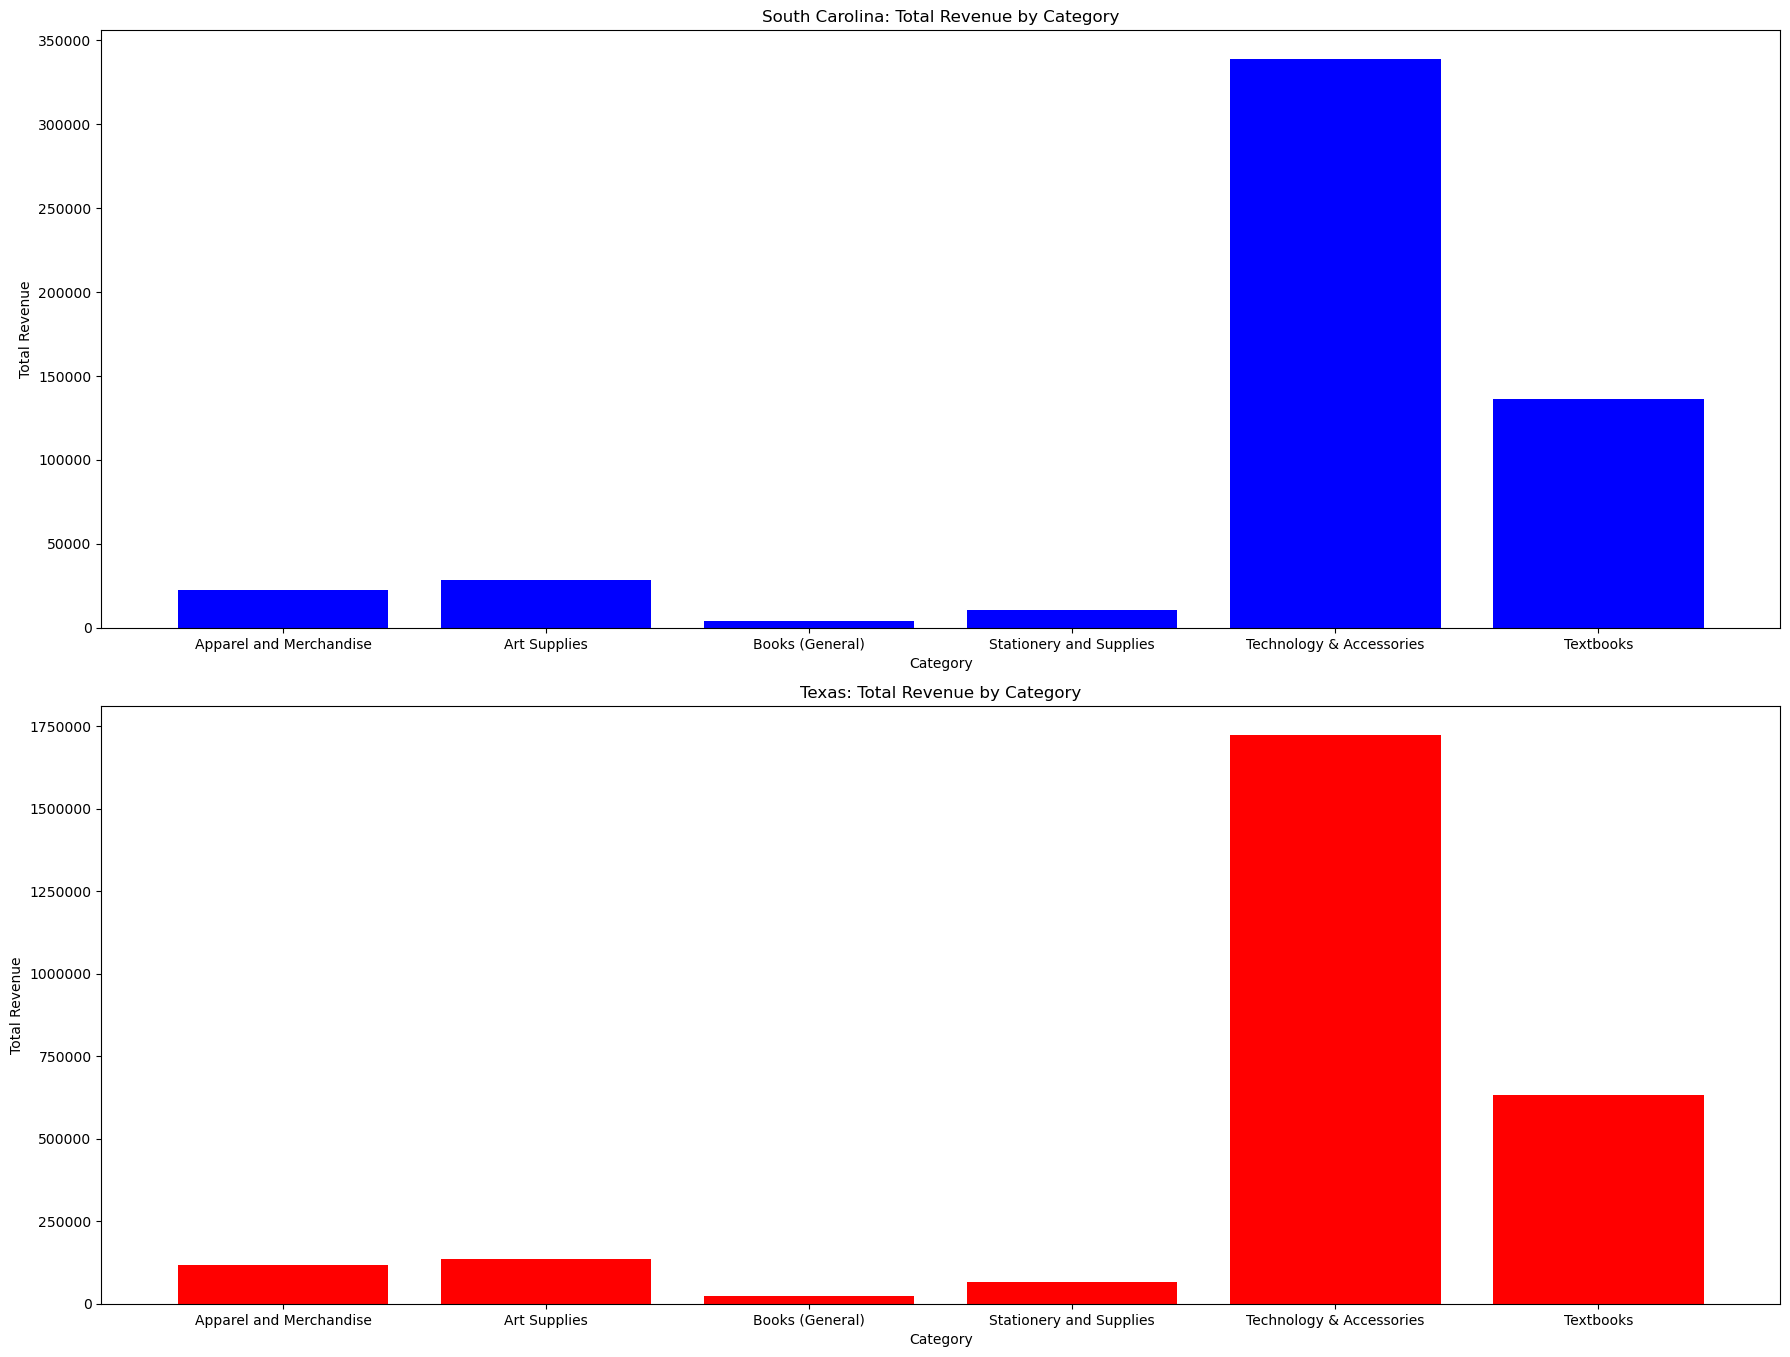

In [37]:
# creating bar charts for categories

# grouping SC by Category & summing total revenue
sc_total_cat = sc_monthly_cat.groupby('Category')['Total_Revenue'].sum().reset_index()

# grouping TX by Category & summing total revenue
tx_total_cat = tx_monthly_cat.groupby('Category')['Total_Revenue'].sum().reset_index()

# comparing average rev per category in each territory
sc_cat_arr = np.array(sc_total_cat['Total_Revenue']) # SC revenue stored
tx_cat_arr = np.array(tx_total_cat['Total_Revenue']) # TX revenue stored

# calculating average rev per category
sc_avg_rev = np.mean(sc_cat_arr) # average for all SC category totals
tx_avg_rev = np.mean(tx_cat_arr) # average for all SC category totals

# displaying results
print("Average Revenue Per Category: South Carolina - $",round(sc_avg_rev,2)) # SC avg
print("Average Revenue Per Category: Texas - $",round(tx_avg_rev,2)) # TX avg


plt.figure(figsize=(18,20)) # setting chart size

# SC chart
plt.subplot(3,1,1) # SC goes first (3 rows, 1 column figure)
plt.bar(sc_total_cat['Category'], sc_total_cat['Total_Revenue'], color='blue') # bar chart for SC Cat
plt.title('South Carolina: Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

# TX chart
plt.subplot(3,1,2) # TX goes second (3 rows, 1 column figure)
plt.bar(tx_total_cat['Category'], tx_total_cat['Total_Revenue'], color='red') # bar chart for TX Cat
plt.title('Texas: Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

# fixing y-axis label
plt.ticklabel_format(style='plain', axis='y') # showing numbers instead of scientific notation

plt.tight_layout() # adjusting spacing for no overlap
# displaying output
plt.show()

#### SC & TX Findings:
Top categories: Technology & Accessories, Textbooks (high-demand products, educational products),
these two are often paired together because students use tech alongside note-taking.

Average Revenue Per Category: South Carolina with `$90,123.40` and Texas with `$449,931.35`. This shows a large difference in how the two states perform. Texas consistently outperforms South Carolina in almost every product category, by generating nearly five times more revenue per category.

Insight: Technology & Accessories bring in higher revenue with fewer transactions, while
Textbooks bring in almost the same amount of revenue with a higher number of transactions. 
The Tech products bring in more revenue due to pricing, while Textbooks create a steady flow by 
being frequent purchases.

Opportunities: Lowest revenues (Books, Apparel & Merchandise, Stationery & Supplies).
They could benefit from doing promotional seasonal bundles & placing items near the front of the
stores, so they are visible to customers.

# Recommendation For Next Quarter:
I recommend focusing on the Texas territory for the next quarter, specifically Beaumont store
location. Beaumont consistently generates the highest total revenue and has the strongest customer
spending across all stores. Texas also shows significantly higher average revenue per product category, indicating a stronger demand and larger purchasing trend overall.

South Carolina shows steady growth, but since they have fewer stores to test strategies
on and lower category performance, Texas offers more opportunities for immediate impact and higher results from marketing strategies.